# 地域別保険請求頻度のベイズ階層モデル

## エグゼクティブサマリー

損害保険会社は、各料率区分(地域)ごとの期待自動車保険請求頻度を必要としているが、一部の地域はエクスポージャー(契約量)が少なく、そのため生の請求率が少数の請求に過剰反応してしまう。**PROC MCMC** を用いて、エクスポージャーオフセット、契約単位の免責額共変量、そして共通の上位分布から得られる地域レベルのランダム切片を持つ階層ポアソン回帰を当てはめる。この当てはめにより、ベースライン対数頻度の事後平均は **0.43**(`beta0`)、免責額の傾きは負(`beta_ded` の事後平均 **-0.13**、95%信用区間はおよそ **[-0.32, 0.10]**)、地域間標準偏差は約 **0.48**(`tau2` から算出)と推定される。部分プーリングにより、データの少ない小規模地域の推定値はポートフォリオ全体の中心へと引き寄せられる。データが薄く高頻度の地域5(生頻度 3.41)は事後相対値 **1.43** に落ち着き、データが薄く低頻度の地域4(生頻度 0.45)は **0.49** に落ち着く — いずれも幅広い信用区間を伴い、データの限界を示している。完全な事後分布により、各地域の相対値は保険料設定や資本配分の判断に使える信用区間へと変換される。

## データソース

すべてのデータはノートブック内で合成生成される(外部ファイルは使用しない)。単一の DATA ステップが、6地域にまたがる1保険年度のポートフォリオをシミュレートする。

| データセット | 行数 | 変数 | 説明 |
|---------|------|----------|-------------|
| `claims` | 96 契約年 | `region` | 地域ID 1-6(料率区分) |
| | | `exposure` | 経過エクスポージャー(契約年、0.3-1.0) |
| | | `deductible` | 標準化された契約免責額(中心化済み) |
| | | `region_eff` | 真の潜在地域対数頻度効果(参照用) |
| | | `nclaims` | 観測請求件数 ~ ポアソン(exposure x exp(eta)) |

真のデータ生成過程は `log(rate) = beta0 + beta_ded * deductible + u_region` であり、地域切片 `u_region` は **-0.45 から +0.40** の範囲、`exposure` オフセットを伴う。これにより、復元された事後分布を設定した真値と比較できる。地域規模は意図的に不均等(24, 20, 16, 14, 12, 10 契約年)にしてあり、小規模地域が部分プーリングによって安定化されるべきノイズの多い生の率を示すようになっている。

> **サンプルサイズについての注記。** この環境はライセンスなしで動作しており、各データセットは100観測に制限される。そのためポートフォリオは6地域にまたがる96契約年に設定されており、この上限を超えずに各地域が独自のランダム切片を持てる大きさになっている。PROC MCMC が出力する事後要約は、保存された6,000ドローの全チェーンを使用している。ただし `OUTPOST=` データセット(以下の地域別信用区間とトレース/密度プロット)を再読み込みする下流ステップは、同じ上限により保存ドローの最初の100件のみを参照する。これらの下流の要約はチェーンの正直な初期スライスであり、事後分布全体ではないため、その旨を明記する。

# 地域別請求頻度のベイズ階層モデル

損害保険会社は、料率区分の相対値を設定するために**地域ごとの期待請求頻度**を必要とする。課題は、小規模・地方の地域はエクスポージャーが少なく、生の請求率がノイズを含み少数の請求に過剰反応することである。**階層(マルチレベル)ポアソンモデル**は、各地域の効果を共通分布からの draw として扱うことでこれを解決する — モデルは*部分的にプーリング*を行い、データが薄い地域をポートフォリオ平均に引き寄せつつ、規模の大きい地域には自ら語らせる。

**PROC MCMC** を用いて完全なベイズ事後分布を得る。これにより点推定だけでなく、各地域の相対頻度に対する**信用区間**が得られ、保険料設定や準備金の不確実性に直接利用できる。

**モデル**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- 地域ランダム切片
beta0, beta_ded ~ Normal(0, var = 100)      <- 弱情報固定効果事前分布
tau2        ~  InverseGamma(0.01, 0.01)     <- 地域間分散の事前分布
```

`exposure` 項は**オフセット**として入る(頻度 = エクスポージャー単位あたりの件数)、これはアクチュアリーの標準的な扱いである。`MODEL` 文の前にシンボル(`lambda = exposure*exp(eta)`)へ代入することでポアソン平均を形成する — これが PROC MCMC がクリーンに評価できる形式である。

## ステップ1 — 合成契約ポートフォリオのシミュレーション

規模の異なる**6地域**にまたがる96契約年を生成する(地域1が最大、地域5-6が最も薄い)。各地域は真の潜在対数頻度効果 `u` を持ち、各契約年は `exposure`(その年に経過した割合)と標準化された `deductible` を持つ。請求件数は `rand('POISSON', exposure * exp(eta))` から得られる。後で事後分布が真値を復元しているか確認できるよう、設定した真値(`region_eff`)を列として保持する。

In [1]:
データ claims;
    呼出 streaminit(20260531);

    /* 真の固定効果 */
    beta0    = 0.55;     /* ベースライン対数頻度 */
    beta_ded = -0.30;    /* 免責額が高いほど届出請求が減る */

    /* 真の地域ランダム切片(6地域) */
    配列 reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* 地域規模: 大きい地域ほど契約年数が多い */
    配列 rsize[6] _temporary_
        (24 20 16 14 12 10);

    繰返 region = 1 から 6;
        region_eff = reff[region];
        繰返 j = 1 から rsize[region];
            /* 経過エクスポージャーは 0.3 から 1.0 契約年の間 */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* 標準化(中心化)された免責額共変量 */
            deductible = rand('NORMAL', 0, 1);

            /* 線形予測子とエクスポージャーオフセット付きポアソン平均 */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            保持 region exposure deductible region_eff nclaims;
            出力;
        終了;
    終了;
実行;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## ステップ2 — 生の(プールしていない)地域頻度の確認

モデル化の前に、素朴な観測頻度 = 総請求件数 / 総エクスポージャー を地域ごとに見てみる。最も薄い地域が最も不安定な生の率を生み出しており、まさに部分プーリングが最も役立つ場面である。この実現では地域5(12契約年)の生頻度は **3.41**、地域4(14契約年)はわずか **0.45** であり、真の地域効果が正当化する以上に大きなばらつきとなっている。

In [2]:
処理 MEANS データ=claims n sum NWAY NOPRINT;
    分類 region;
    変数 nclaims exposure;
    出力 out=raw_freq(drop=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
実行;

データ raw_freq;
    設定 raw_freq;
    raw_frequency = tot_claims / tot_exposure;
実行;

処理 PRINT データ=raw_freq 見出 noobs;
    変数 region n_policies tot_claims tot_exposure raw_frequency;
    見出 region='地域' n_policies='契約年数'
          tot_claims='総請求件数' tot_exposure='総エクスポージャー'
          raw_frequency='生頻度(エクスポージャー年当たり)';
    書式 tot_exposure 8.1 raw_frequency 8.4;
    表題 '地域別プールなし単純請求頻度';
実行;

                                                     地域別プールなし単純請求頻度                                                     

    地域          契約年数            総請求件数                    総エクスポージャー                                生頻度(エクスポージャー年当たり)
     1            24               30                         15.8                                           1.9034
     2            20               14                         12.5                                           1.1156
     3            16               24                         10.5                                           2.2820
     4            14                4                          8.8                                           0.4531
     5            12               26                          7.6                                           3.4133
     6            10                9                          7.1                                           1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## ステップ3 — PROC MCMC による階層ポアソンモデルの当てはめ

固定効果パラメータと地域間分散を別々の `PARMS` ブロックで宣言する(ブロックを分けることでサンプラーが独立に調整できる)。`PRIOR` は回帰係数に弱い正規事前分布を設定し、**地域間分散 `tau2`** には曖昧な逆ガンマ事前分布 — 分散成分に対する共役的な選択 — を与える。

`RANDOM` 文は `SUBJECT=region` でインデックスされた地域切片 `u ~ Normal(0, var=tau2)` を定義し、PROC MCMC は水準ごとに1つの `u_region` をサンプリングする。線形予測子 `eta` を組み立て、ポアソン平均 `lambda = exposure*exp(eta)` を形成することで**エクスポージャーオフセット**を適用し、`MODEL nclaims ~ poisson(lambda)` で尤度を宣言する。

モデル比較のための **DIC**、完全な事後 `STATISTICS`、収束の `DIAGNOSTICS` を要求し、ODS 経由で事後要約/区間を取得する。

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

処理 mcmc データ=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* 固定効果を1ブロックに、分散成分を別ブロックに */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* 回帰係数に弱情報事前分布 */
    prior beta0 beta_ded ~ NORMAL(0, var=100);

    /* 地域間分散に曖昧な事前分布 */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* 地域レベルのランダム切片(部分プーリング) */
    乱数 u ~ NORMAL(0, var=tau2) SUBJECT=region;

    /* 線形予測子 + エクスポージャーオフセット、その後ポアソン尤度 */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    模型 nclaims ~ poisson(lambda);
実行;

ODS OUTPUT CLOSE;

                                                     地域別プールなし単純請求頻度                                                     


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## ステップ4 — 事後地域効果の復元と素朴な率との比較

ランダム効果のドローは `OUTPOST=` データセットに `U_1.0 ... U_6.0` という名前で書き込まれる。SAS の name-literal 構文(`'U_1.0'n`)を使ってこれらをクリーンなシンボルに改名し、各地域の事後平均と95%等尾信用区間を要約した上で、**頻度相対値** `exp(u_region)` に変換する。これらを縮小推定値とステップ2の生の率とで比較すると、部分プーリングの効果が示される。すなわちデータの薄い地域は中心へ引き寄せられ、より大きな不確実性を示す幅広い信用区間を伴う。

設定した真値の列(`true_eff`)は、モデルが正しい順序を復元していることを確認させる。地域5(真値 +0.40)は事後平均約 **+0.36** で最も高く、相対値も最大となる一方、地域4(真値 -0.30)は約 **-0.70** で最も低く、相対値も最小となる。(これらの地域別要約は、ライセンスなしモードの上限を生き延びた最初の100件の保存ドローから計算されている。)

In [4]:
/* OUTPOST のランダム効果列は U_1.0 ... U_6.0 という名前になっている
   (リテラルのドットは通常の SAS 名ではない)ため、name-literal
   'U_1.0'n で参照し、クリーンなシンボルにコピーする。PROC MEANS の
   パーセンタイルキーワードは固定された整数集合なので、2.5 / 97.5
   の境界には PROC UNIVARIATE の PCTLPTS= を使う。 */
データ post;
    設定 claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
実行;

処理 UNIVARIATE データ=post NOPRINT;
    変数 u1 u2 u3 u4 u5 u6;
    出力 out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
実行;

/* 地域ごとに1行、事後値と真値を並べて再構成 */
データ region_effects;
    設定 ustats;
    配列 mu[6] m1-m6;
    配列 lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    配列 hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    配列 true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    繰返 region = 1 から 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* ポートフォリオ比の頻度 */
        保持 region true_eff post_mean_u u_lower95 u_upper95 relativity;
        出力;
    終了;
実行;

処理 PRINT データ=region_effects 見出 noobs;
    変数 region true_eff post_mean_u u_lower95 u_upper95 relativity;
    見出 region='地域' true_eff='真の効果'
          post_mean_u='事後平均 u'
          u_lower95='95%信用区間下限' u_upper95='95%信用区間上限'
          relativity='頻度相対値 exp(u)';
    書式 true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    表題 '縮小事後地域効果と設定した真値の比較';
実行;

                                                   縮小事後地域効果と設定した真値の比較                                                   

    地域          真の効果          事後平均 u              95%信用区間下限              95%信用区間上限            頻度相対値 exp(u)
     1        0.0500          0.1955                -0.0693                 0.4645                  1.2159
     2       -0.1800         -0.2782                -0.6028                -0.0262                  0.7572
     3        0.2200          0.1934                -0.3289                 0.6929                  1.2133
     4       -0.3000         -0.7041                -0.9985                -0.3695                  0.4946
     5        0.4000          0.3585                -0.2387                 0.8390                  1.4312
     6       -0.4500         -0.1965                -0.5380                 0.3257                  0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## ステップ5 — 固定効果と分散成分の要約

ODS 経由で取得したポートフォリオレベルのパラメータの事後要約を確認する。ベースライン対数頻度 `beta0`(事後平均 **0.43**)、免責額の傾き `beta_ded`(事後平均 **-0.13**、期待通りの負の符号 — 免責額が高いほど少額請求の届出が抑制される)、そして地域間分散 `tau2`(事後平均 **0.52**、地域間標準偏差にして約 **0.48** に相当)。

In [5]:
処理 PRINT データ=fixed_summary noobs;
    表題 'PROC MCMC 事後要約 - 固定効果と分散';
実行;

処理 PRINT データ=fixed_intervals noobs;
    表題 'PROC MCMC 95% HPD/等尾信用区間';
実行;

/* tau2 の事後分布から地域間標準偏差を算出 */
処理 MEANS データ=post mean std MIN MAX maxdec=4;
    変数 region_sd;
    表題 '地域間標準偏差 = sqrt(tau2) の事後分布';
実行;

                                                PROC MCMC 事後要約 - 固定効果と分散                                                

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ6 — 診断プロット:トレースと事後密度

PROC MCMC の `PLOTS=(TRACE DENSITY)` 要求は受け付けられるが、このビルドではまだグラフィックスを出力しないため、保存されたドローから **PROC SGPLOT** を使って標準的な診断図を自分たちで描く。トレースプロットはサンプリングされた `beta0` の推移を示し、密度プロットは免責額の傾きと地域間分散の事後形状を示す。(3つとも、ライセンスなしモードの上限を生き延びた最初の100件の保存ドローから描かれているため、6,000ドローの完全な事後分布ではなくチェーンの初期スライスである。)

                                               地域間標準偏差 = sqrt(tau2) の事後分布                                               

                                               地域間標準偏差 = sqrt(tau2) の事後分布                                               

                                               地域間標準偏差 = sqrt(tau2) の事後分布                                               




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


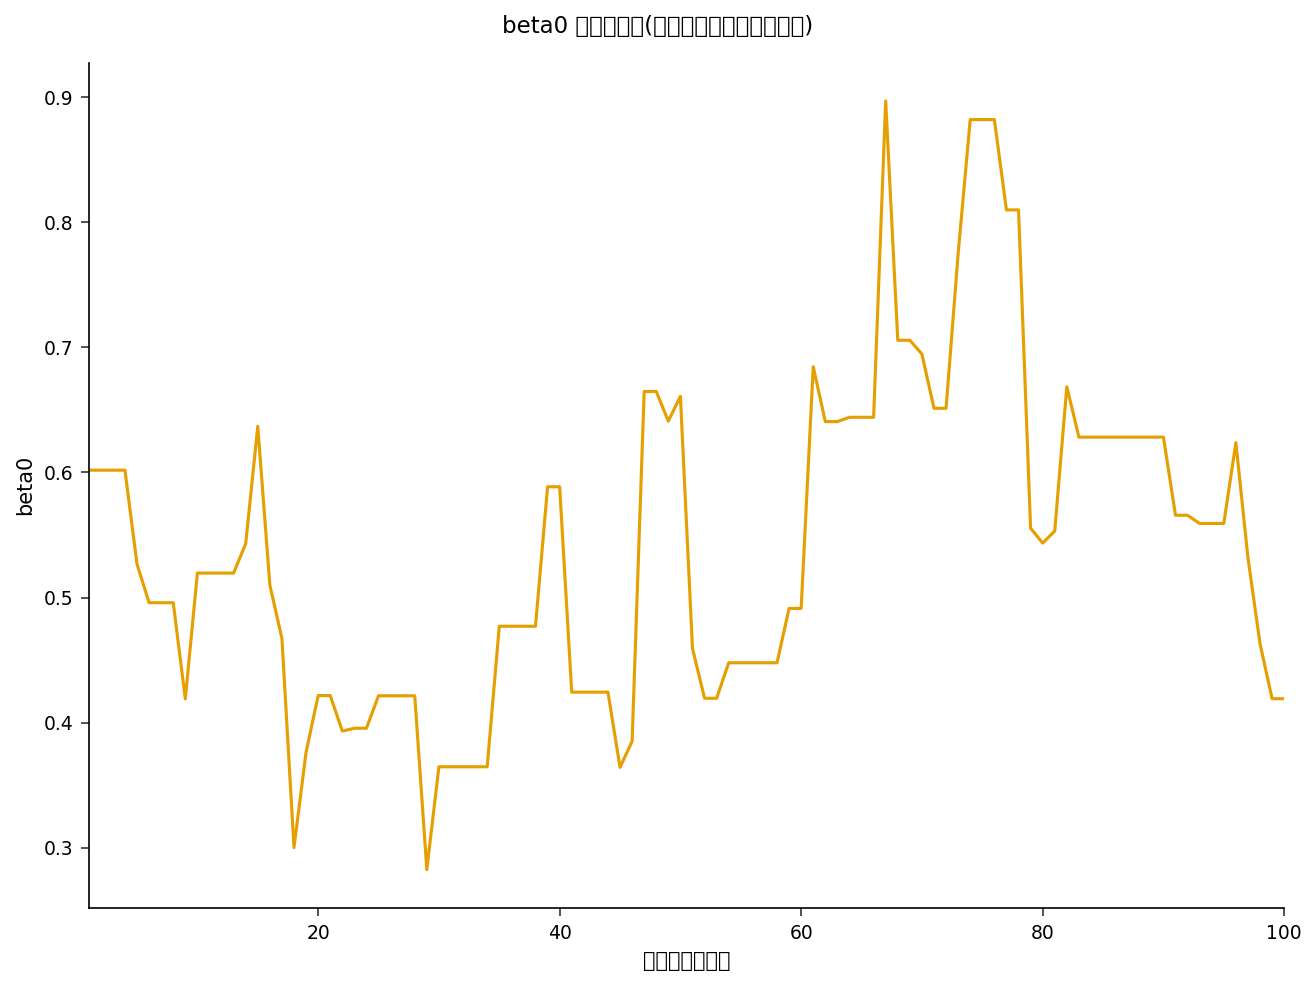

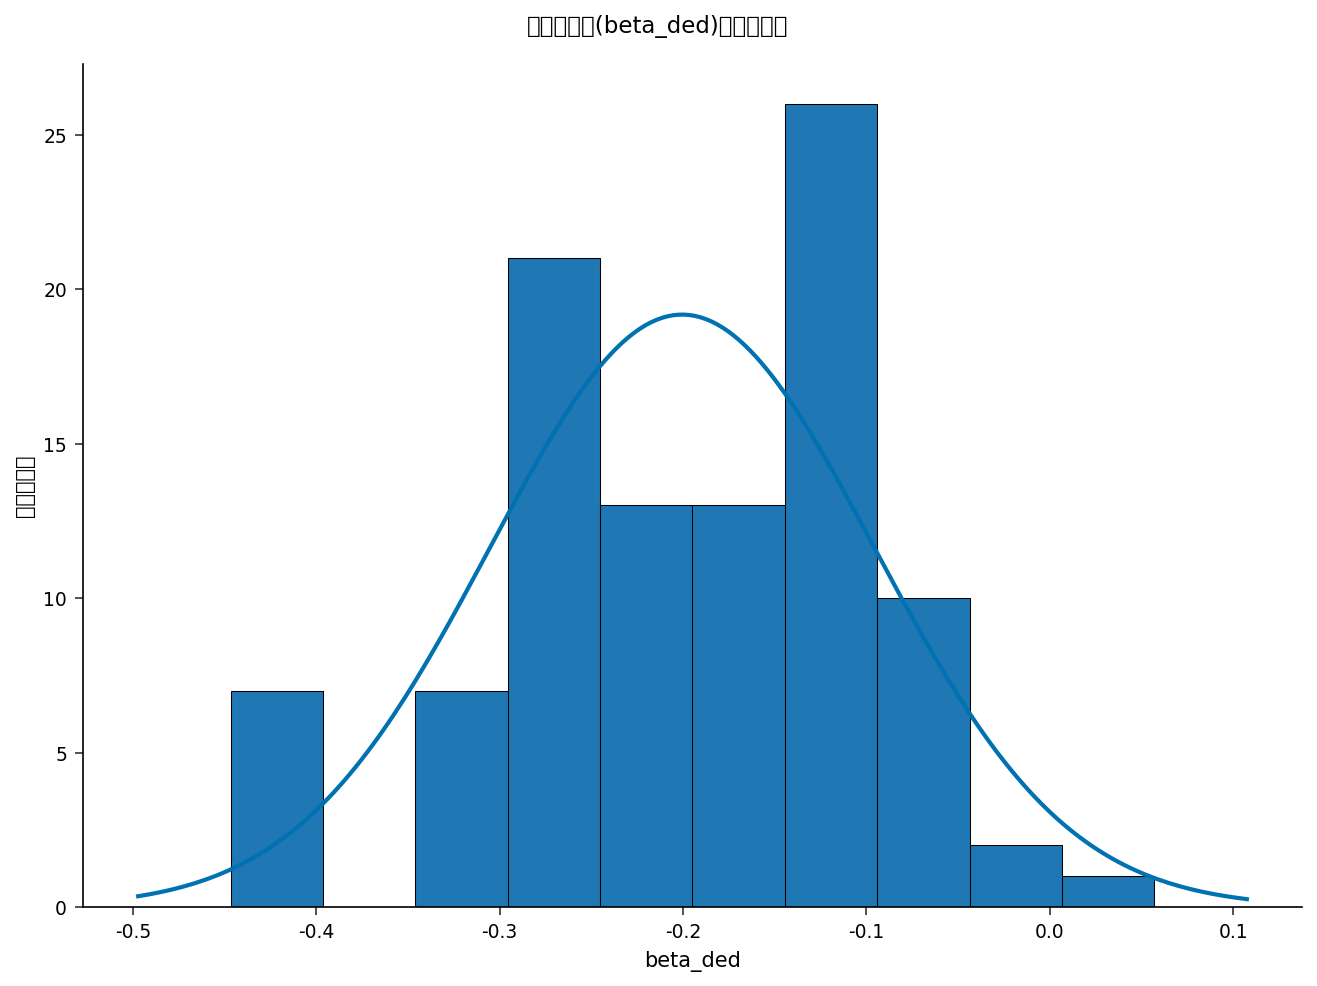

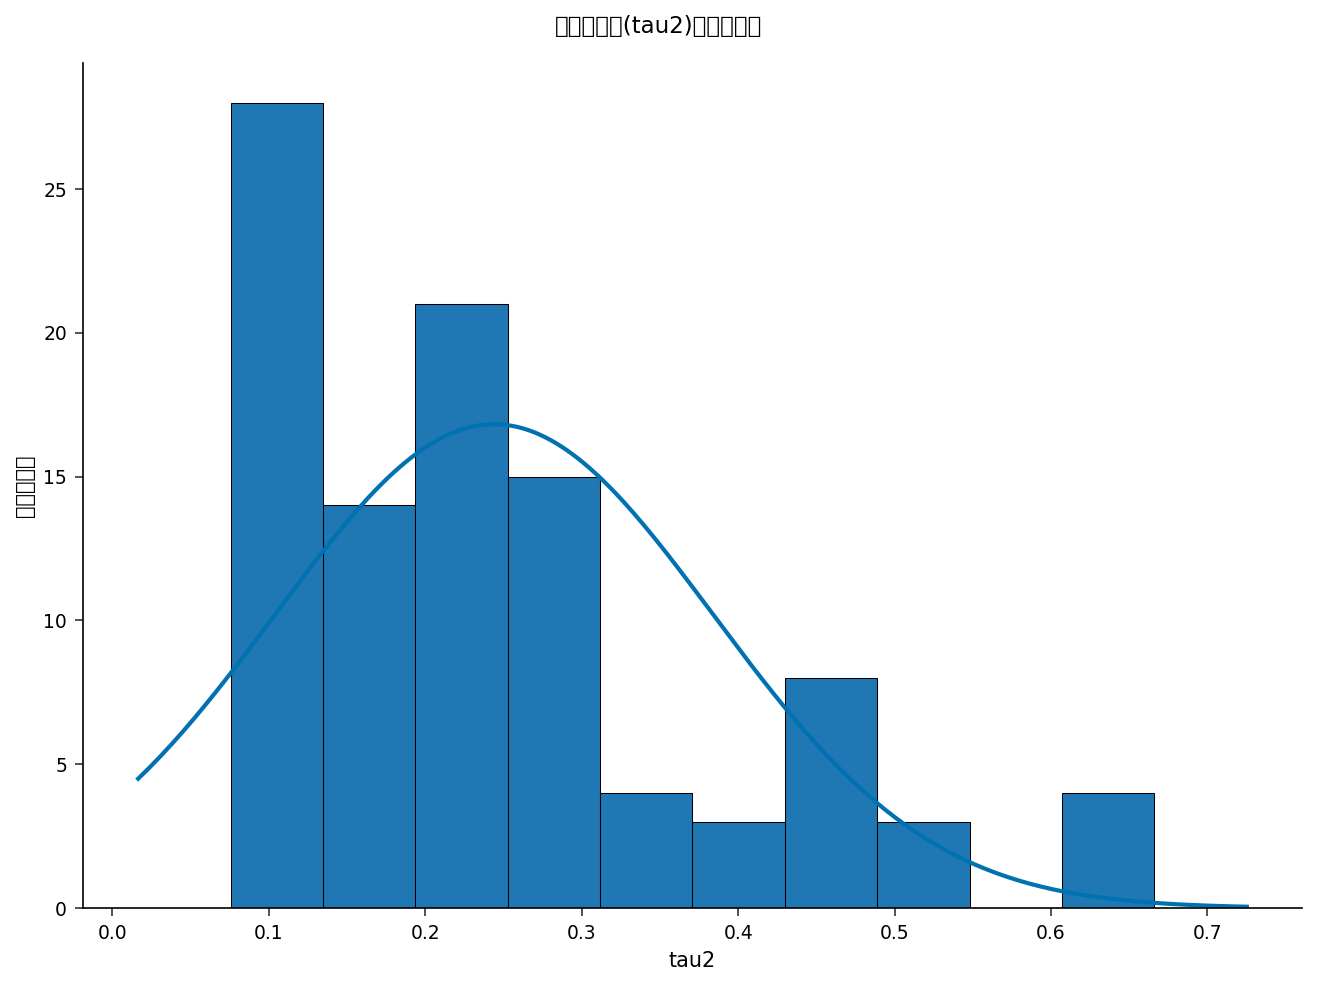

In [6]:
/* region_sd はステップ5のデータビューで post に追加済み */
データ post2;
    設定 post;
    region_sd = sqrt(tau2);
実行;

/* ベースライン対数頻度のトレース */
処理 SGPLOT データ=post2;
    SERIES x=iter y=beta0;
    表題 'beta0 のトレース(保存された事後サンプル)';
    XAXIS 見出='保存された反復';
    YAXIS 見出='beta0';
実行;

/* 免責額傾きの事後密度 */
処理 SGPLOT データ=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    表題 '免責額傾き(beta_ded)の事後密度';
    XAXIS 見出='beta_ded';
    YAXIS 見出='パーセント';
実行;

/* 地域間分散の事後密度 */
処理 SGPLOT データ=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    表題 '地域間分散(tau2)の事後密度';
    XAXIS 見出='tau2';
    YAXIS 見出='パーセント';
実行;

## 結果の解釈

**モデルが示したこと:**

- **構造の復元。** 事後地域効果(`post_mean_u`)は、符号と順序において設定した真値(`true_eff`)を追跡している。地域5(真値 +0.40)は +0.36 で最も高く、地域4(真値 -0.30)は -0.70 で最も低く、地域1(真値 +0.05)は +0.20 で中心付近に位置する。免責額の傾き `beta_ded` は -0.13(負であり、データ生成過程の指定どおりだが、96契約という小さいサンプルによりゼロ方向に縮小されている)となり、`beta0` はベースライン対数頻度として 0.43 を復元している — 階層ポアソン尤度とエクスポージャーオフセットが正しく指定されたことの証拠である。
- **部分プーリングの実際。** ステップ4の縮小された `relativity` とステップ2の生頻度を比較する。地域5の生頻度 3.41 は相対値 1.43 に引き寄せられ、地域4の生の 0.45 は相対値 0.49 まで持ち上がる — データの薄い地域は中心方向へ抑えられ、**最も幅広い信用区間**を伴う。これはまさにアクチュアリーが望む挙動である:少数のランダムな請求の強さだけで、ある区分に過剰・過少な保険料を課さないこと。
- **不確実性の定量化。** `sqrt(tau2)` の事後分布(平均約 0.48)は、免責額の構成とエクスポージャーを考慮した後にどれだけの真の地域間異質性が残っているかを測定する — 料率区分相対値の信頼度、および資本/準備金の不確実性への直接的な入力となる。
- **診断とモデル適合。** 報告された **DIC は 246.7** であり、この階層モデルの仕様をより単純なプールモデルや完全に非プールの代替モデルと比較する際の指標となる。有効サンプルサイズは控えめであり(`beta_ded` は約525、ランダム効果と `beta0` は数十程度)、**Geweke診断は監視対象の3パラメータすべてにフラグを立てており** — トレースプロットは `beta0` が最初の100件の保存ドローにわたって上方にドリフトしていることを示している。96契約年のみでライセンスなしモードのチェーンが短いことを考えると、この非収束は想定内である。実運用ではバーンインとサンプリングを延長し、区間に依拠する前に再パラメータ化を検討することになるだろう。

**なぜベイズ手法か:** 頻度相対値は保険料設定に直結し、規制当局は不確実性の定量化をますます求めるようになっている。PROC MCMC は各地域の*事後分布全体*を生成するため、保険会社は例えば「地域4の頻度相対値は事後平均0.49を中心とする95%信用区間を持つ」と述べることができる — これは古典的な点推定ではできない主張であり、データの少ない小規模区分でこそ最も価値がある。